# Transaction Processing Analysis

This notebook analyses the propagation and processing of transactions throughout a single simulation run.

## 1. Load Libraries and Data

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Enable copy-on-write to follow pandas recommendation.
# see https://pandas.pydata.org/docs/user_guide/copy_on_write.html
pd.options.mode.copy_on_write = True

In [56]:
# Replace '../output.csv' with the path to your CSV file
# As a reminder, please run `go run ./daphne run` to produce this file
data = pd.read_csv('../output.csv')

# Filter rows with relevant 'mark' values
data = data[data['mark'].str.startswith('Tx')]

## 2. Transaction Processing Rate
The following chart illustrates the transaction processing rate per second over the duration of the evaluation.

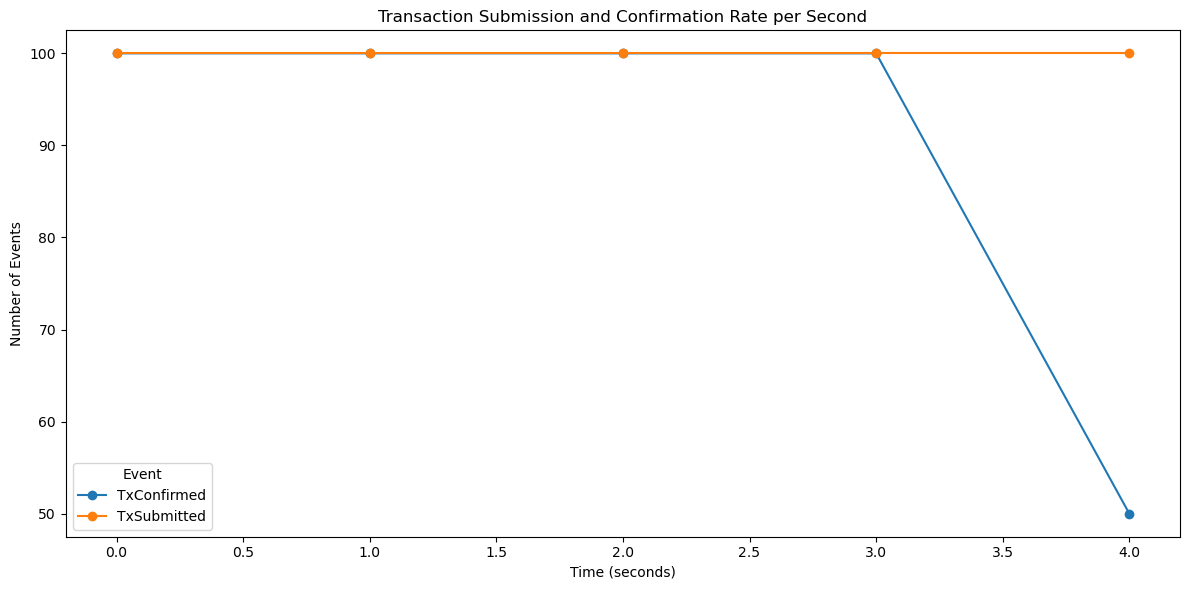

In [57]:
# Convert timestamp to seconds (assuming timestamp is in nanoseconds)
data['time_sec'] = (data['timestamp'] - data['timestamp'].min()) / 1e9

# Filter for TxSubmitted and TxConfirmed events
submitted_confirmed = data[data['mark'].isin(['TxSubmitted', 'TxConfirmed'])]

# For each hash and mark, keep only the earliest event
unique_events = submitted_confirmed.sort_values('timestamp').groupby(['hash', 'mark'], as_index=False).first()

# Bin by second
unique_events['second'] = unique_events['time_sec'].astype(int)

# Count per second for each event type
rate_per_second = unique_events.groupby(['second', 'mark']).size().unstack(fill_value=0)

# Plot
plt.figure(figsize=(12, 6))
rate_per_second.plot(ax=plt.gca(), marker='o')
plt.xlabel('Time (seconds)')
plt.ylabel('Number of Events')
plt.title('Transaction Submission and Confirmation Rate per Second')
plt.legend(title='Event')
plt.tight_layout()
plt.show()

## 3. Transaction Latency

The following chart plots the distribution of the Time To Finality (TTF) of all transactions processed during the simulation. For this, the TTF of a transaction T is defined as the time delay between the first RPC receiving the transaction and the first moment the transaction's receipt was ready on any node.

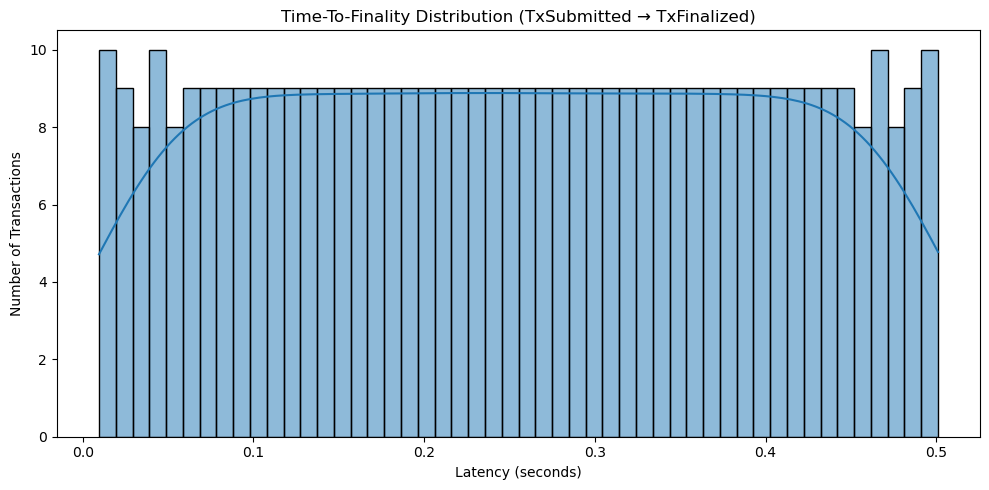

In [58]:
# Find first TxSubmitted and TxFinalized timestamps per transaction (in nanoseconds)
submitted = data[data['mark'] == 'TxSubmitted'].sort_values('timestamp').groupby('hash', as_index=False).first()
finalized = data[data['mark'] == 'TxFinalized'].sort_values('timestamp').groupby('hash', as_index=False).first()

# Merge to get both timestamps per transaction
latency_df = pd.merge(
    submitted[['hash', 'timestamp']],
    finalized[['hash', 'timestamp']],
    on='hash',
    suffixes=('_submitted', '_finalized')
)

# Compute latency in seconds from nanoseconds
latency_df['latency'] = (latency_df['timestamp_finalized'] - latency_df['timestamp_submitted']) / 1e9

# Plot latency distribution
plt.figure(figsize=(10, 5))
sns.histplot(latency_df['latency'], bins=50, kde=True)
plt.xlabel('Latency (seconds)')
plt.ylabel('Number of Transactions')
plt.title('Time-To-Finality Distribution (TxSubmitted → TxFinalized)')
plt.tight_layout()
plt.show()

The following chart shows the latency distribution between the first and last node in the network reaching the finalization point of a transaction.

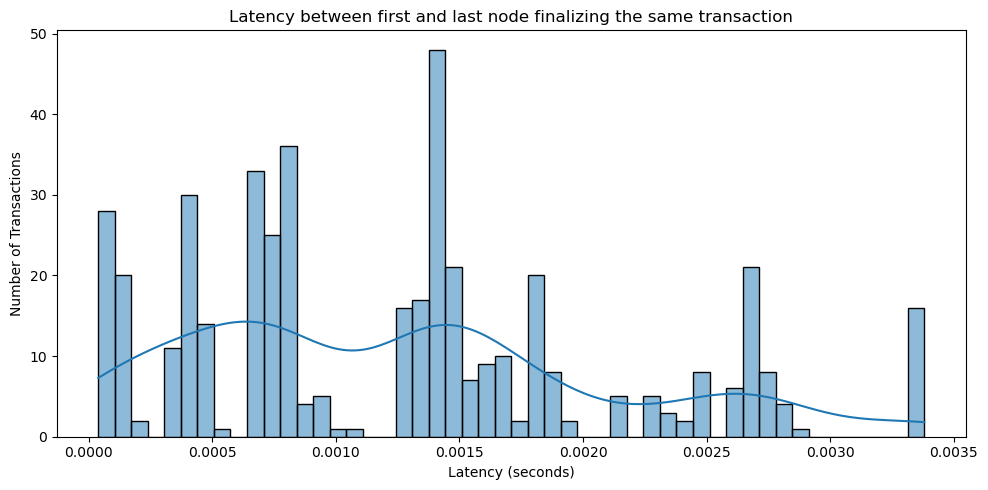

In [59]:
# Find first and last TxFinalized timestamps per transaction (in nanoseconds)
earliest = data[data['mark'] == 'TxFinalized'].sort_values('timestamp').groupby('hash', as_index=False).first()
latest = data[data['mark'] == 'TxFinalized'].sort_values('timestamp').groupby('hash', as_index=False).last()

# Merge to get both timestamps per transaction
latency_df = pd.merge(
    earliest[['hash', 'timestamp']],
    latest[['hash', 'timestamp']],
    on='hash',
    suffixes=('_earliest', '_latest')
)

# Compute latency in seconds from nanoseconds
latency_df['latency'] = (latency_df['timestamp_latest'] - latency_df['timestamp_earliest']) / 1e9

# Plot latency distribution
plt.figure(figsize=(10, 5))
sns.histplot(latency_df['latency'], bins=50, kde=True)
plt.xlabel('Latency (seconds)')
plt.ylabel('Number of Transactions')
plt.title('Latency between first and last node finalizing the same transaction')
plt.tight_layout()
plt.show()

## 4. Transaction Pool Dynamics

The following examine how the transaction pool behaves over time, including pool fill rates, pool latency, and pool rejection patterns.

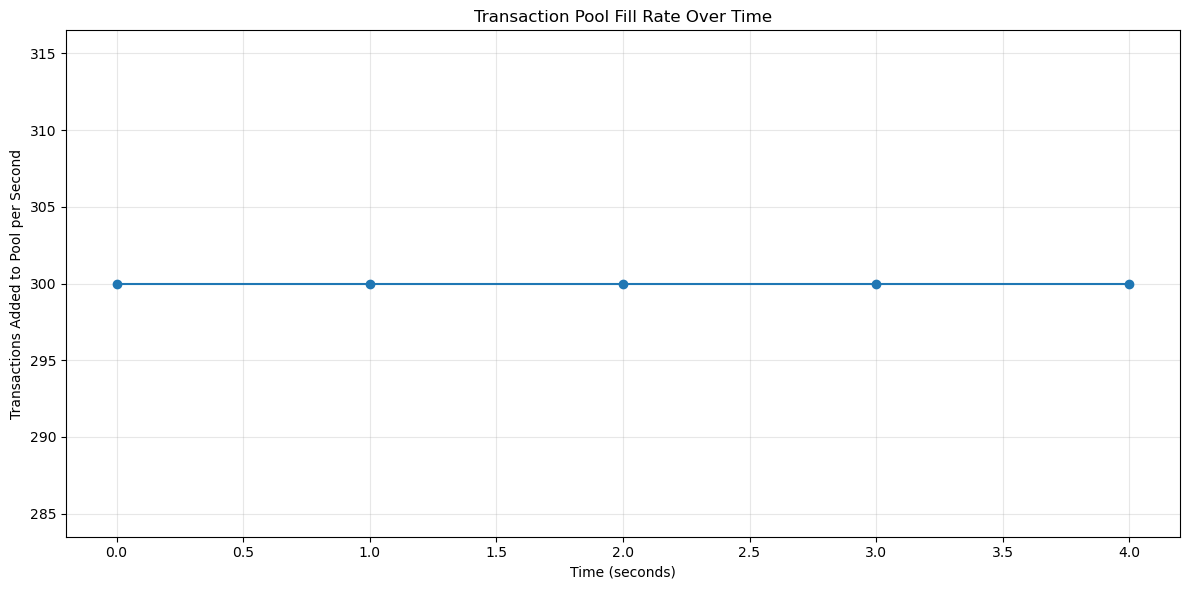

In [60]:
# Pool fill rate over time: Track TxAddedToPool events to show pool growth/drain patterns
pool_events = data[data['mark'] == 'TxAddedToPool'].copy()
pool_events['time_sec'] = (pool_events['timestamp'] - data['timestamp'].min()) / 1e9

# Bin by second and count additions to pool
pool_events['second'] = pool_events['time_sec'].astype(int)
pool_rate_per_second = pool_events.groupby('second').size()

plt.figure(figsize=(12, 6))
pool_rate_per_second.plot(kind='line', marker='o')
plt.xlabel('Time (seconds)')
plt.ylabel('Transactions Added to Pool per Second')
plt.title('Transaction Pool Fill Rate Over Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

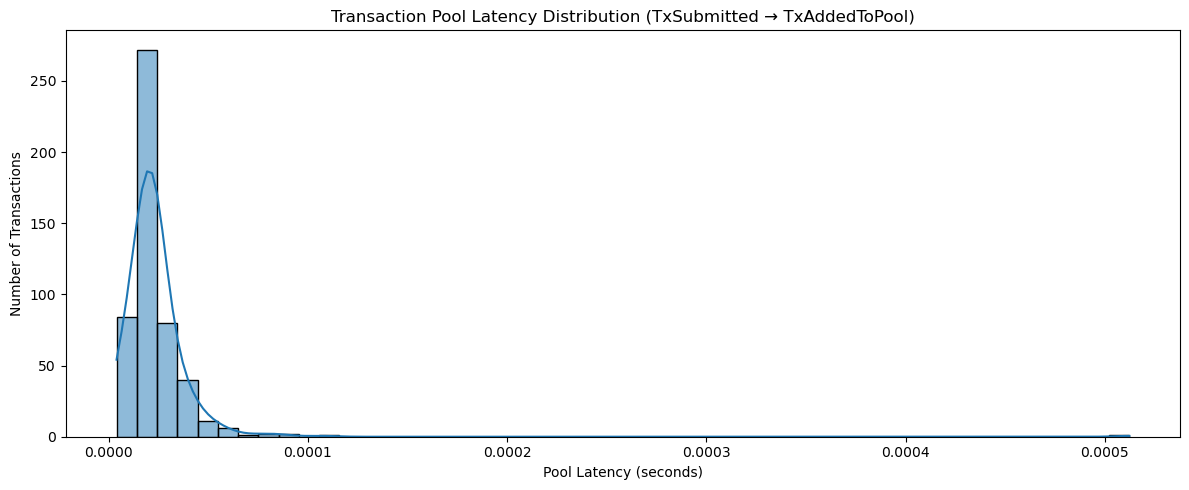

In [61]:
# Pool latency: Time between TxSubmitted and TxAddedToPool per transaction
pool_submitted = data[data['mark'] == 'TxSubmitted'].sort_values('timestamp').groupby('hash', as_index=False).first()
pool_added = data[data['mark'] == 'TxAddedToPool'].sort_values('timestamp').groupby('hash', as_index=False).first()

pool_latency_df = pd.merge(
    pool_submitted[['hash', 'timestamp']],
    pool_added[['hash', 'timestamp']],
    on='hash',
    suffixes=('_submitted', '_added')
)

pool_latency_df['pool_latency'] = (pool_latency_df['timestamp_added'] - pool_latency_df['timestamp_submitted']) / 1e9

plt.figure(figsize=(12, 5))
sns.histplot(pool_latency_df['pool_latency'], bins=50, kde=True)
plt.xlabel('Pool Latency (seconds)')
plt.ylabel('Number of Transactions')
plt.title('Transaction Pool Latency Distribution (TxSubmitted → TxAddedToPool)')
plt.tight_layout()
plt.show()

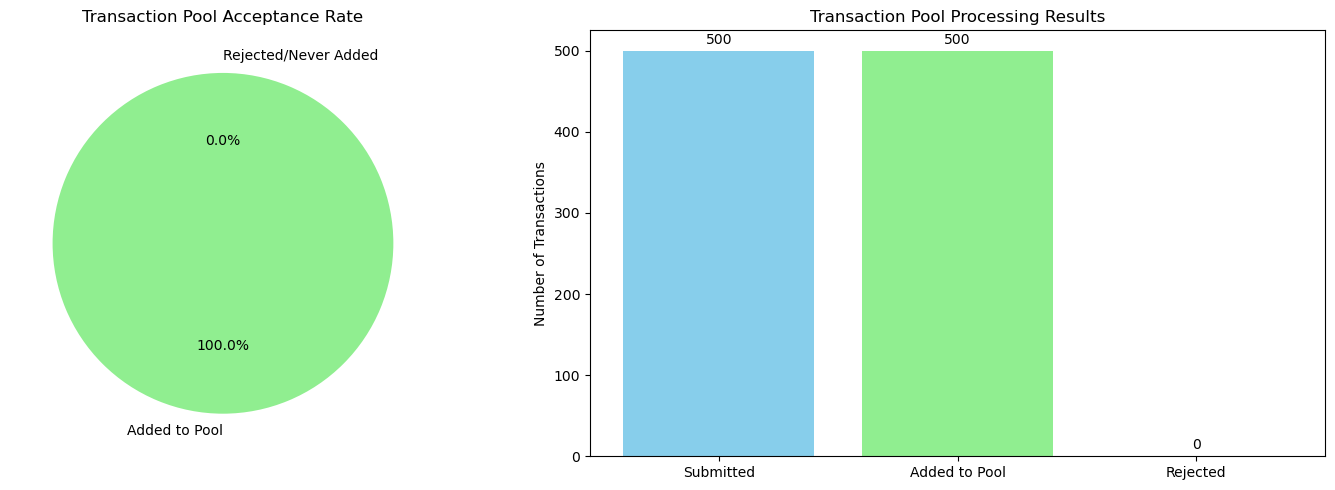

In [62]:
# Pool rejection analysis: Identify transactions that were submitted but never added to pool
submitted_hashes = set(data[data['mark'] == 'TxSubmitted']['hash'].unique())
added_hashes = set(data[data['mark'] == 'TxAddedToPool']['hash'].unique())
rejected_hashes = submitted_hashes - added_hashes

rejection_stats = {
    'Total Submitted': len(submitted_hashes),
    'Successfully Added to Pool': len(added_hashes),
    'Rejected/Never Added': len(rejected_hashes),
    'Rejection Rate': len(rejected_hashes) / len(submitted_hashes) * 100 if submitted_hashes else 0
}

# Visualize rejection rate
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Pie chart of acceptance vs rejection
labels = ['Added to Pool', 'Rejected/Never Added']
sizes = [len(added_hashes), len(rejected_hashes)]
colors = ['lightgreen', 'lightcoral']
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title('Transaction Pool Acceptance Rate')

# Bar chart
categories = ['Submitted', 'Added to Pool', 'Rejected']
values = [len(submitted_hashes), len(added_hashes), len(rejected_hashes)]
bars = ax2.bar(categories, values, color=['skyblue', 'lightgreen', 'lightcoral'])
ax2.set_ylabel('Number of Transactions')
ax2.set_title('Transaction Pool Processing Results')

# Add value labels on bars
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + max(values)*0.01,
             str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 5. Transaction Processing Pipeline

This section analyzes the transaction processing pipeline, showing the duration of each stage and identifying potential bottlenecks.

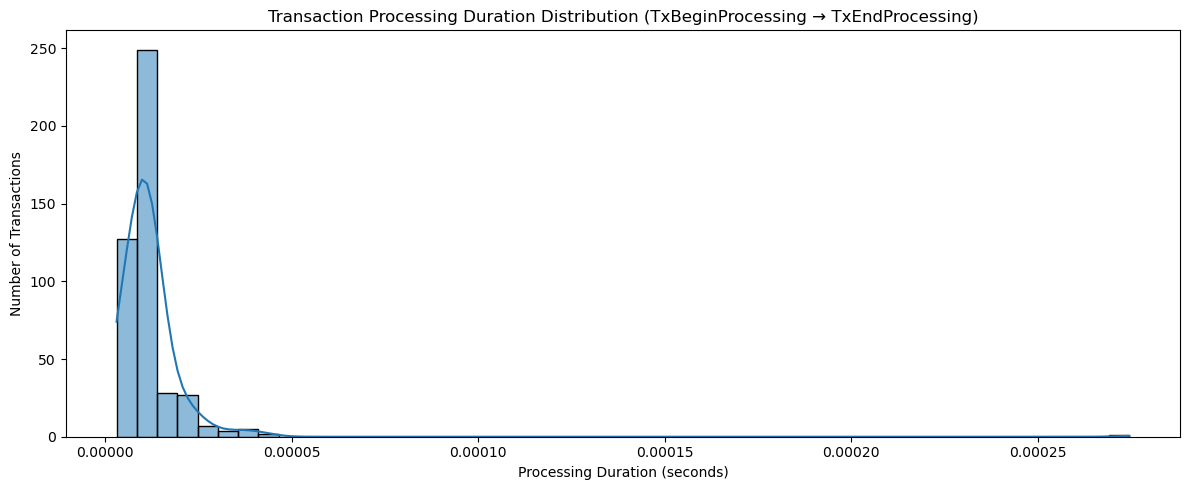

In [63]:
# Processing duration distribution: Time between TxBeginProcessing → TxEndProcessing
begin_processing = data[data['mark'] == 'TxBeginProcessing'].sort_values('timestamp').groupby('hash', as_index=False).first()
end_processing = data[data['mark'] == 'TxEndProcessing'].sort_values('timestamp').groupby('hash', as_index=False).first()

processing_duration_df = pd.merge(
    begin_processing[['hash', 'timestamp']],
    end_processing[['hash', 'timestamp']],
    on='hash',
    suffixes=('_begin', '_end')
)

processing_duration_df['processing_duration'] = (processing_duration_df['timestamp_end'] - processing_duration_df['timestamp_begin']) / 1e9

plt.figure(figsize=(12, 5))
sns.histplot(processing_duration_df['processing_duration'], bins=50, kde=True)
plt.xlabel('Processing Duration (seconds)')
plt.ylabel('Number of Transactions')
plt.title('Transaction Processing Duration Distribution (TxBeginProcessing → TxEndProcessing)')
plt.tight_layout()
plt.show()

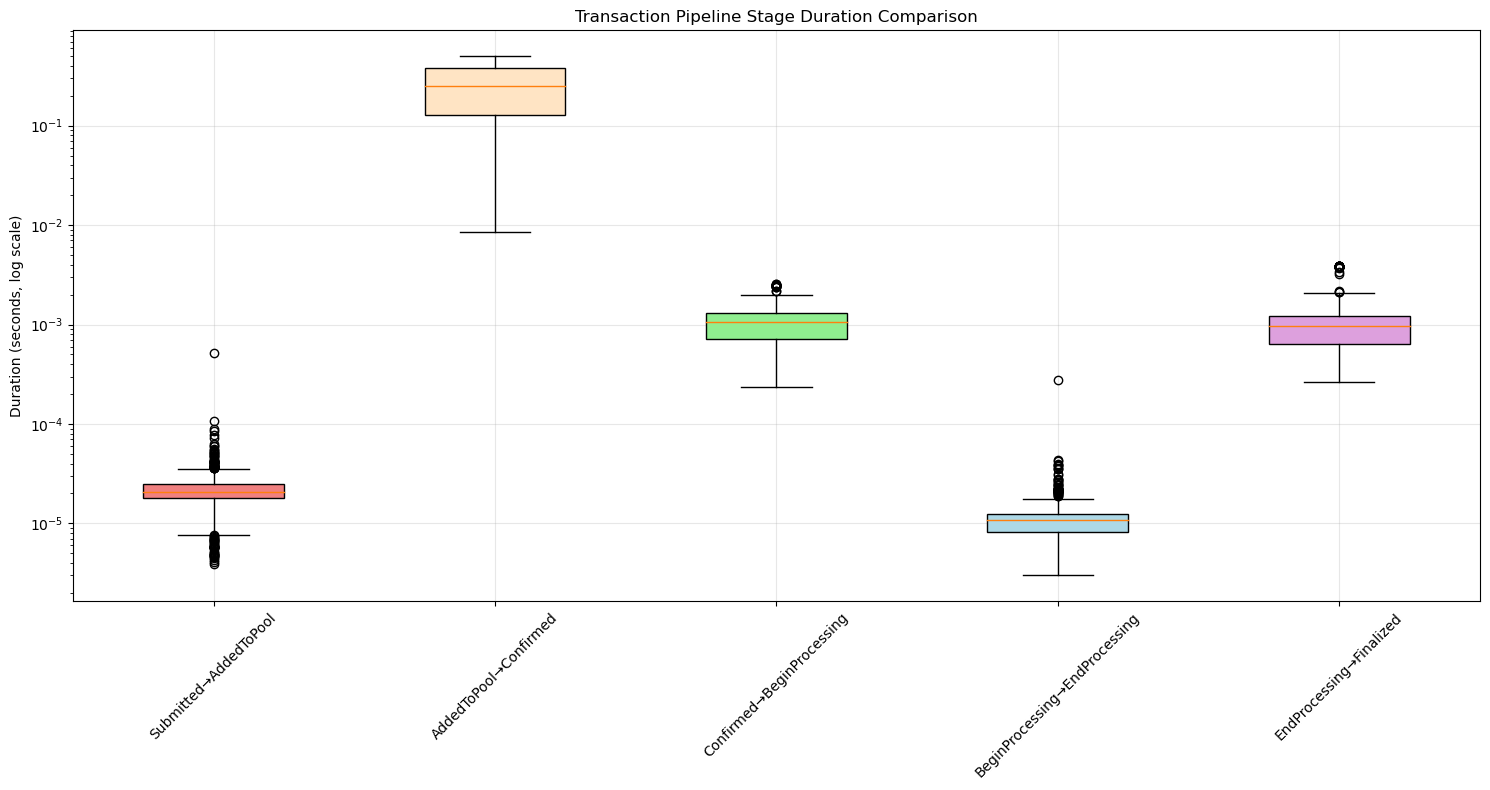

In [64]:
# Pipeline stage breakdown: Calculate duration for each pipeline stage
pipeline_stages = {}

# Get first occurrence of each mark per transaction
stages = ['TxSubmitted', 'TxAddedToPool', 'TxConfirmed', 'TxBeginProcessing', 'TxEndProcessing', 'TxFinalized']
for mark_name in stages:
    stage_data = data[data['mark'] == mark_name].sort_values('timestamp').groupby('hash', as_index=False).first()
    pipeline_stages[mark_name] = stage_data[['hash', 'timestamp']]

# Find transactions that have all stages
all_hashes = None
for stage_name, stage_data in pipeline_stages.items():
    stage_hashes = set(stage_data['hash'])
    if all_hashes is None:
        all_hashes = stage_hashes
    else:
        all_hashes = all_hashes.intersection(stage_hashes)


# Calculate stage durations for complete transactions
stage_durations = []
stage_names = ['Submitted→AddedToPool', 'AddedToPool→Confirmed', 'Confirmed→BeginProcessing', 
               'BeginProcessing→EndProcessing', 'EndProcessing→Finalized']

for tx_hash in list(all_hashes):
    tx_stages = {}
    for mark_name, stage_data in pipeline_stages.items():
        tx_data = stage_data[stage_data['hash'] == tx_hash]
        if not tx_data.empty:
            tx_stages[mark_name] = tx_data.iloc[0]['timestamp']
    
    # Verify all stages are present
    if len(tx_stages) == len(stages): 
        # the assumption is that timestamps are in nanoseconds
        durations = {
            'Submitted→AddedToPool': (tx_stages['TxAddedToPool'] - tx_stages['TxSubmitted']) / 1e9,
            'AddedToPool→Confirmed': (tx_stages['TxConfirmed'] - tx_stages['TxAddedToPool']) / 1e9,
            'Confirmed→BeginProcessing': (tx_stages['TxBeginProcessing'] - tx_stages['TxConfirmed']) / 1e9,
            'BeginProcessing→EndProcessing': (tx_stages['TxEndProcessing'] - tx_stages['TxBeginProcessing']) / 1e9,
            'EndProcessing→Finalized': (tx_stages['TxFinalized'] - tx_stages['TxEndProcessing']) / 1e9,
        }
        durations['hash'] = tx_hash
        stage_durations.append(durations)

if stage_durations:
    stage_df = pd.DataFrame(stage_durations)
    
    # Create box plot for stage comparison
    plt.figure(figsize=(15, 8))
    stage_data_for_plot = [stage_df[stage].dropna() for stage in stage_names]
    
    bp = plt.boxplot(stage_data_for_plot, labels=stage_names, patch_artist=True)
    # https://matplotlib.org/stable/gallery/color/named_colors.html
    colors = ['lightcoral', 'bisque', 'lightgreen', 'lightblue', 'plum']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    plt.yscale('log')  # Use log scale due to potentially large differences
    plt.ylabel('Duration (seconds, log scale)')
    plt.title('Transaction Pipeline Stage Duration Comparison')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Node-Level Analysis

This section examines how different nodes in the network process transactions, comparing throughput and synchronization patterns.

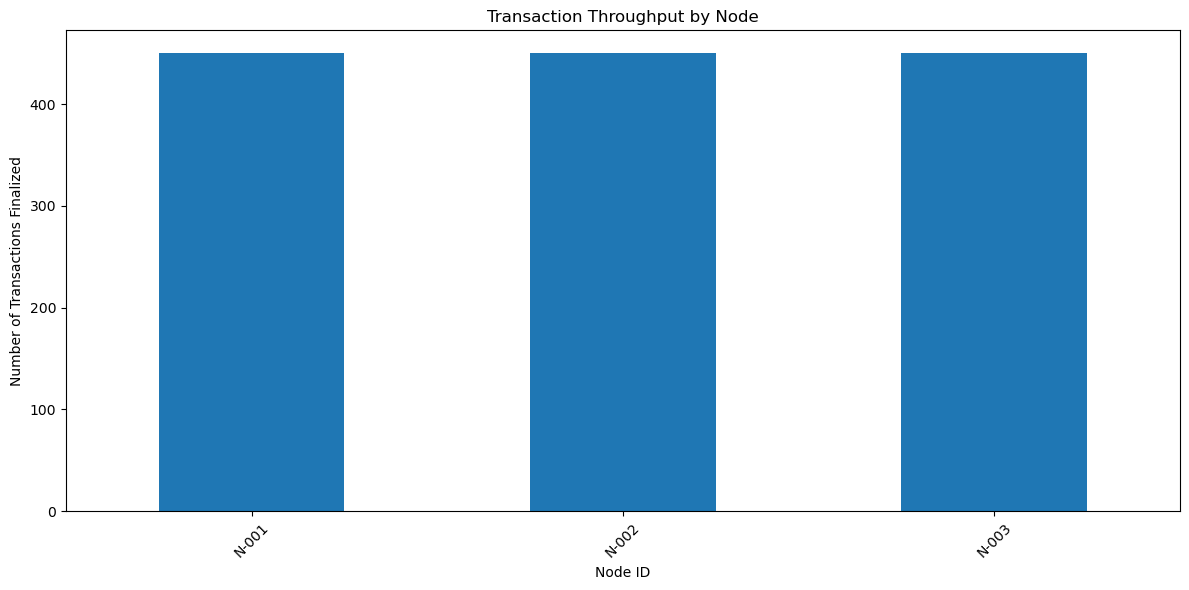

In [72]:
# Per-node processing rates: Compare transaction throughput across different nodes
# Check if 'node' column exists in the data
if 'node' in data.columns:
    node_throughput = data[data['mark'] == 'TxFinalized'].groupby('node').size().sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    node_throughput.plot(kind='bar')
    plt.xlabel('Node ID')
    plt.ylabel('Number of Transactions Finalized')
    plt.title('Transaction Throughput by Node')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

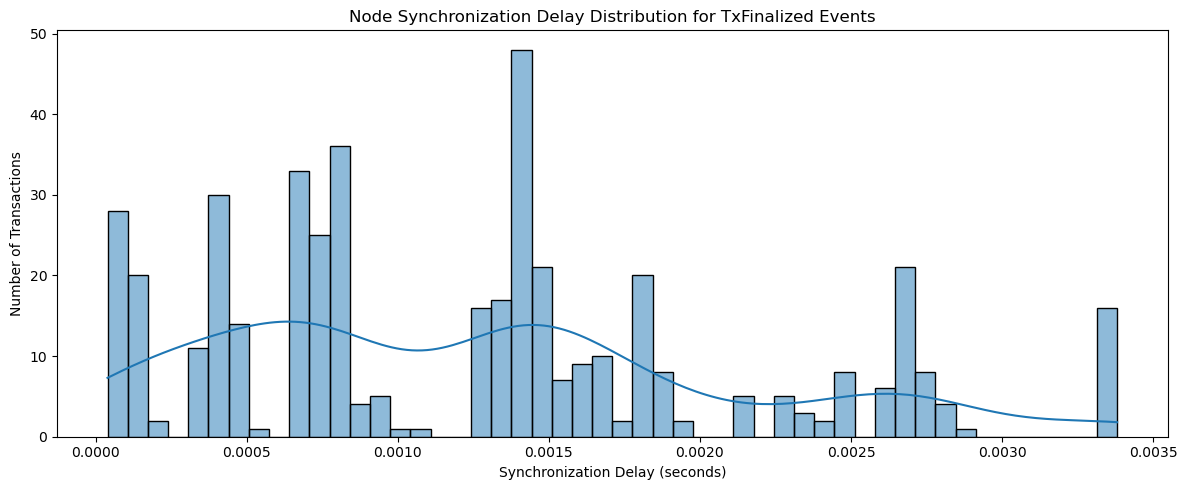

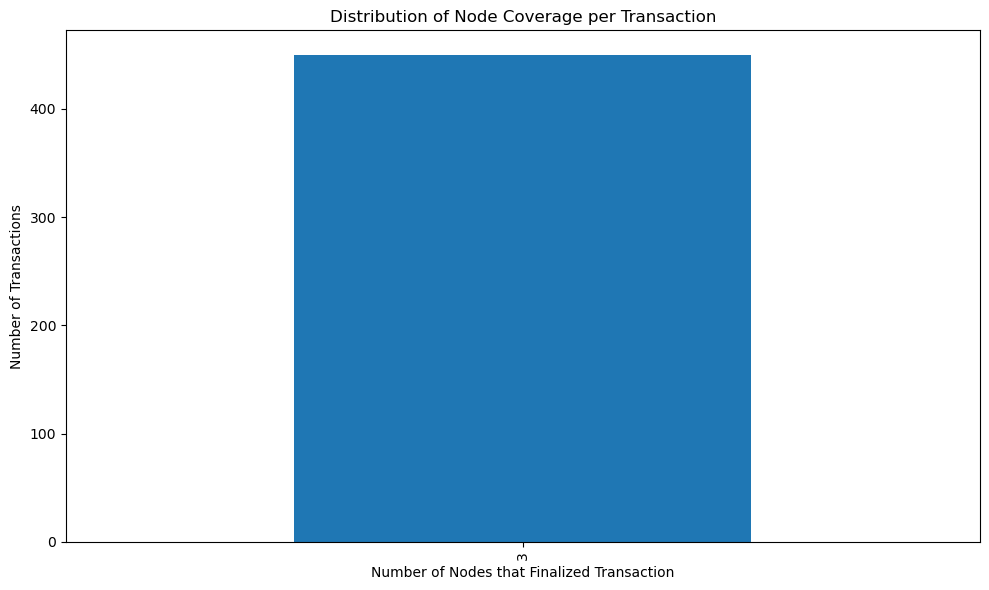

In [66]:
# Node synchronization patterns: Time variance between nodes reaching same transaction states
if 'node' in data.columns:
    # Analyze synchronization for TxFinalized events
    finalized_events = data[data['mark'] == 'TxFinalized'].copy()
    finalized_events['time_sec'] = (finalized_events['timestamp'] - data['timestamp'].min()) / 1e9
    
    # Calculate min and max finalization time per transaction across nodes
    sync_analysis = finalized_events.groupby('hash')['time_sec'].agg(['min', 'max', 'count']).reset_index()
    sync_analysis['sync_delay'] = sync_analysis['max'] - sync_analysis['min']
    sync_analysis = sync_analysis[sync_analysis['count'] > 1]  # Only transactions seen by multiple nodes
    
    if not sync_analysis.empty:
        plt.figure(figsize=(12, 5))
        sns.histplot(sync_analysis['sync_delay'], bins=50, kde=True)
        plt.xlabel('Synchronization Delay (seconds)')
        plt.ylabel('Number of Transactions')
        plt.title('Node Synchronization Delay Distribution for TxFinalized Events')
        plt.tight_layout()
        plt.show()
        
        # Show distribution of how many nodes see each transaction
        plt.figure(figsize=(10, 6))
        node_count_dist = sync_analysis['count'].value_counts().sort_index()
        node_count_dist.plot(kind='bar')
        plt.xlabel('Number of Nodes that Finalized Transaction')
        plt.ylabel('Number of Transactions')
        plt.title('Distribution of Node Coverage per Transaction')
        plt.tight_layout()
        plt.show()

## 7. Transaction Success/Failure Analysis

This section analyzes transaction success rates, failure patterns, and retry behaviors.

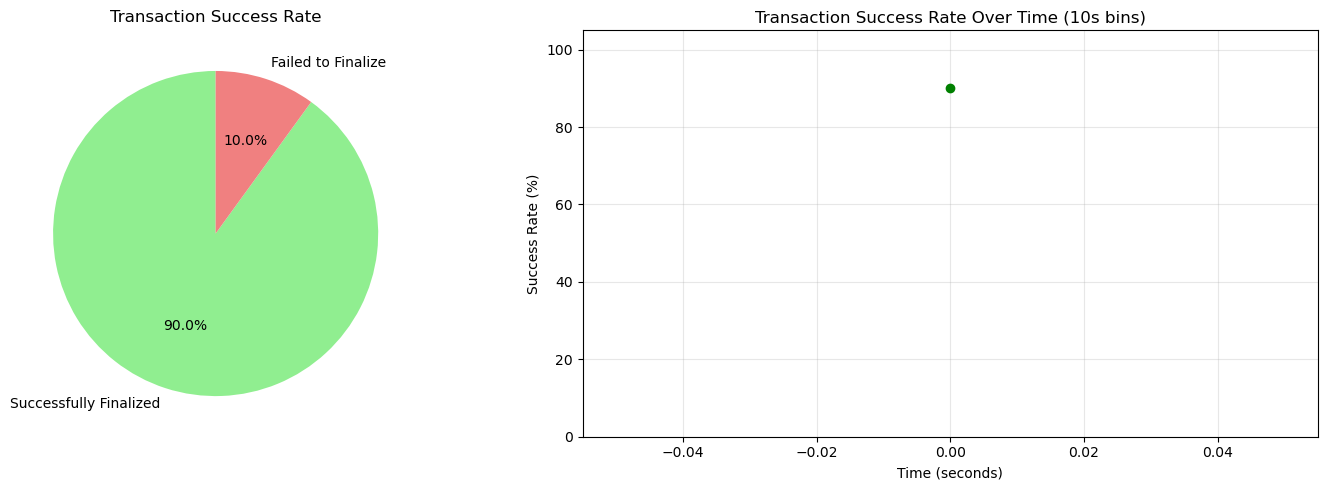

In [ ]:
# Success rate analysis - using finalization as an indicator of success
submitted_tx = set(data[data['mark'] == 'TxSubmitted']['hash'].unique())
finalized_tx = set(data[data['mark'] == 'TxFinalized']['hash'].unique())
failed_tx = submitted_tx - finalized_tx

success_stats = {
    'Total Submitted': len(submitted_tx),
    'Successfully Finalized': len(finalized_tx),
    'Failed to Finalize': len(failed_tx),
    'Success Rate': len(finalized_tx) / len(submitted_tx) * 100 if submitted_tx else 0
}

# Visualize success vs failure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Pie chart
labels = ['Successfully Finalized', 'Failed to Finalize']
sizes = [len(finalized_tx), len(failed_tx)]
colors = ['lightgreen', 'lightcoral']
wedges, texts, autotexts = ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title('Transaction Success Rate')

# Success rate over time
submitted_over_time = data[data['mark'] == 'TxSubmitted'].copy()
submitted_over_time['time_sec'] = (submitted_over_time['timestamp'] - data['timestamp'].min()) / 1e9
submitted_over_time['time_bin'] = (submitted_over_time['time_sec'] / 10).astype(int)  # 10-second bins

finalized_over_time = data[data['mark'] == 'TxFinalized'].copy()
finalized_over_time['time_sec'] = (finalized_over_time['timestamp'] - data['timestamp'].min()) / 1e9
finalized_over_time['time_bin'] = (finalized_over_time['time_sec'] / 10).astype(int)

submitted_counts = submitted_over_time.groupby('time_bin')['hash'].nunique()
finalized_counts = finalized_over_time.groupby('time_bin')['hash'].nunique()

# Align the time bins
all_bins = sorted(set(submitted_counts.index) | set(finalized_counts.index))
submitted_aligned = [submitted_counts.get(bin, 0) for bin in all_bins]
finalized_aligned = [finalized_counts.get(bin, 0) for bin in all_bins]

success_rate_over_time = [
    (fin / sub * 100) if sub > 0 else 0 
    for fin, sub in zip(finalized_aligned, submitted_aligned)
]

ax2.plot([bin * 10 for bin in all_bins], success_rate_over_time, 'o-', color='green')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Success Rate (%)')
ax2.set_title('Transaction Success Rate Over Time (10s bins)')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

In [73]:
# Retry behavior detection: Look for duplicate transaction hashes being submitted
submission_events = data[data['mark'] == 'TxSubmitted'].copy()
hash_submission_counts = submission_events['hash'].value_counts()

retry_stats = {
    'Unique transactions': len(hash_submission_counts),
    'Transactions with retries': (hash_submission_counts > 1).sum(),
    'Total submission events': hash_submission_counts.sum(),
    'Retry rate': ((hash_submission_counts > 1).sum() / len(hash_submission_counts) * 100) if len(hash_submission_counts) > 0 else 0
}

if (hash_submission_counts > 1).any():
    # Show distribution of retry attempts
    retry_distribution = hash_submission_counts[hash_submission_counts > 1].value_counts().sort_index()
    
    plt.figure(figsize=(10, 6))
    retry_distribution.plot(kind='bar')
    plt.xlabel('Number of Submission Attempts')
    plt.ylabel('Number of Transactions')
    plt.title('Distribution of Retry Attempts')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8. Network Propagation Metrics

This section analyzes how transactions propagate through the network and identifies orphaned transactions.

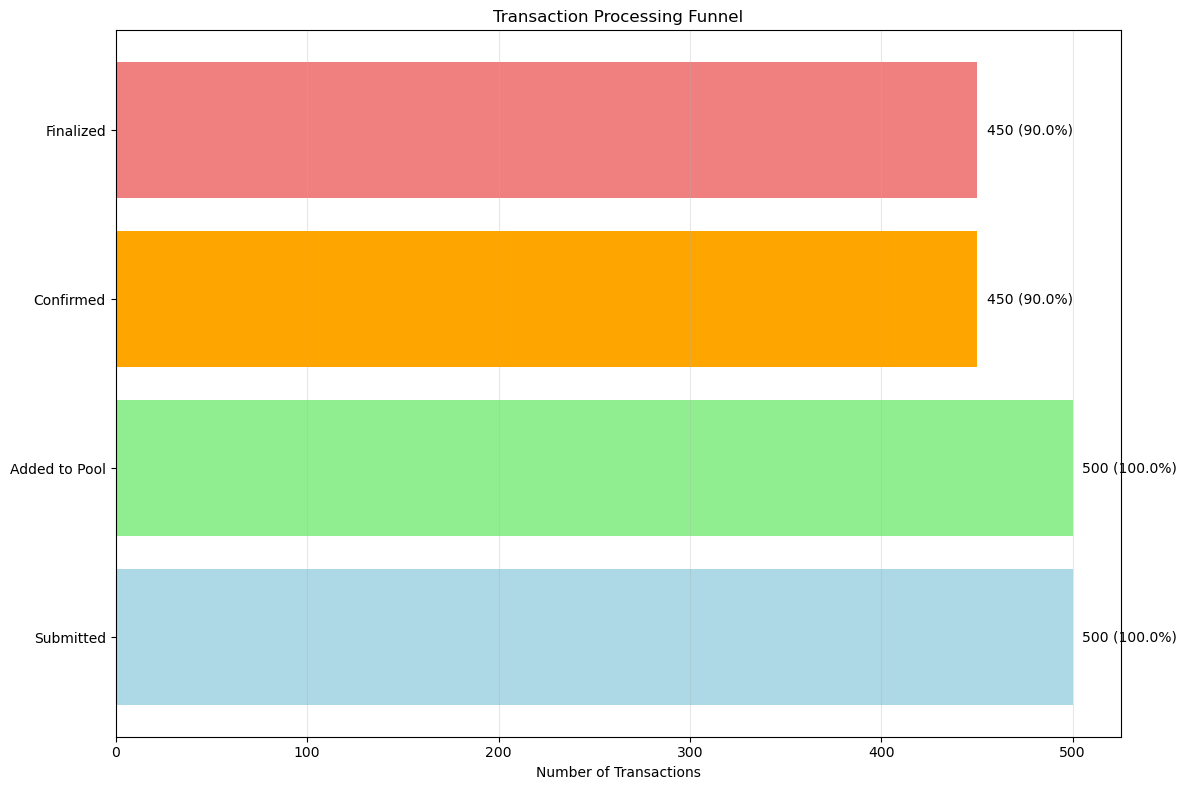

In [ ]:
# Orphaned transactions: Transactions that never reach finalization 
# (i.e., confirmed but not finalized)
# They form part of a Bundle but not a Block
confirmed_tx = set(data[data['mark'] == 'TxConfirmed']['hash'].unique())
finalized_tx = set(data[data['mark'] == 'TxFinalized']['hash'].unique())
orphaned_tx = confirmed_tx - finalized_tx

orphan_stats = {
    'Confirmed transactions': len(confirmed_tx),
    'Finalized transactions': len(finalized_tx),
    'Orphaned transactions': len(orphaned_tx),
    'Orphan rate': (len(orphaned_tx) / len(confirmed_tx) * 100) if confirmed_tx else 0
}

# Visualize the transaction funnel
stages = ['Submitted', 'Added to Pool', 'Confirmed', 'Finalized']
counts = [
    len(set(data[data['mark'] == 'TxSubmitted']['hash'].unique())),
    len(set(data[data['mark'] == 'TxAddedToPool']['hash'].unique())),
    len(confirmed_tx),
    len(finalized_tx)
]

plt.figure(figsize=(12, 8))
colors = ['lightblue', 'lightgreen', 'orange', 'lightcoral']

# Create funnel chart
y_positions = range(len(stages))
bars = plt.barh(y_positions, counts, color=colors)

# Add percentage labels
total_submitted = counts[0] if counts[0] > 0 else 1
for i, (bar, count) in enumerate(zip(bars, counts)):
    percentage = (count / total_submitted) * 100
    plt.text(bar.get_width() + max(counts)*0.01, bar.get_y() + bar.get_height()/2, 
             f'{count} ({percentage:.1f}%)', ha='left', va='center')

plt.yticks(y_positions, stages)
plt.xlabel('Number of Transactions')
plt.title('Transaction Processing Funnel')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()